# Übung 11

**Gruppenname:**

*Name Ihrer Gruppe*

Gehen Sie wie folgt vor:

1. Kopieren Sie jetzt dieses Jupyter Notebook in Ihren Ordner (`Abgaben/Team_WXYZ`)

2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Falls Sie das Notebook im Browser bearbeiten, vergessen Sie nicht, es regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...

... werden wir uns mit Merkmalen (Features) und einfachen Modellen Klassifikatoren erzeugen und die Genauigkeit dieser Modelle mit verschiedenen Metriken bewerten. In Übung 11.1 werden wir uns mit Schwellwert-basierten Modellen beschäftigen. Übung 11.2 behandelt die Klassifikation über eine einfache Form des Nächste Nachbarn Modells. Ziel aller Übungen ist es, Sie mit datengetriebener Modellierung und der Evaluation von Klassifikatoren vertraut zu machen.

### 11.1 Frau und Mann (EDA, ROC, AUC)

In dieser Übung werden wir uns mit den Daten des [National Health and Nutrition Examination Survey](https://de.wikipedia.org/wiki/National_Health_and_Nutrition_Examination_Survey) aus den Jahren 2009-2010 beschäftigen, die verschiedene Gesundheitsdaten der amerikanischen Bevölkerung umfassen. Wir werden zunächst in einer explorativen Datenanalyse (EDA) den Datensatz untersuchen. In einem zweiten Schritt werden wir daran arbeiten, mithilfe von Merkmalen (Features) Frauen und Männer zu unterscheiden, ohne dabei die Angabe des Geschlechts (Merkmal *"Gender"*) in den Daten zu nutzen. Das Resultat ist ein ganz einfaches Klassifikationsmodell, dessen Genauigkeit wir mithilfe verschiedener Metriken untersuchen werden.

**Ihre Daten**

* Sie finden die Daten, die Sie für diese Übung benötigen, im Git Repository unter `data/nhanes-data.csv`.

**Ihre Aufgaben**

(1) Importieren Sie die Daten und untersuchen Sie: Welche Merkmale (Features) enthält der Datensatz? (Hinweis: Das *Gender*-Merkmal kodiert, ob es sich um einen Mann (1) oder um eine Frau (0) handelt.)

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

df = pd.read_csv("../data/nhanes-data.csv", delimiter="\t")

n_samples, m_features = df.shape
cols = df.columns
cols = ["Gender", "Age_in_days", "Weight_in_kg", "Heigh_in_cm", "Leg_Length_in_cm", "Arm_length_in_cm", "Arm_circum_length", "Wais_in_cm"]
df.columns = cols

print(f"{df.shape}, ")
print(cols)

df

(4979, 8), 
['Gender', 'Age_in_days', 'Weight_in_kg', 'Heigh_in_cm', 'Leg_Length_in_cm', 'Arm_length_in_cm', 'Arm_circum_length', 'Wais_in_cm']


,Gender,Age_in_days,Weight_in_kg,Heigh_in_cm,Leg_Length_in_cm,Arm_length_in_cm,Arm_circum_length,Wais_in_cm
0,0,241,64.7,163,34.2,36.2,29.0,89.6
1,0,241,54.0,153,37.2,34.0,26.1,85.5
2,1,241,61.4,165,37.7,35.0,31.4,70.1
3,0,241,74.0,171,37.9,36.2,29.8,91.1
4,0,241,63.6,159,38.1,34.0,29.2,74.3
...,...,...,...,...,...,...,...,...
4974,1,958,89.5,184,43.0,42.8,32.2,112.8
4975,0,959,78.6,151,35.6,34.2,33.5,114.9
4976,1,959,86.5,175,38.6,41.5,32.8,100.2
4977,0,959,58.0,163,40.2,37.5,26.2,82.8


(2) Führen Sie eine EDA auf den Daten (zunächst ohne das *Gender* Merkmal) durch. Erstellen Sie unter anderem eine [Scattermatrix](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.plotting.scatter_matrix.html) und erzeugen Sie auch paarweise [Korrelationskoeffizienten](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html) (Pearson), um zu untersuchen, ob es Zusammenhänge zwischen den Merkmalen gibt. Notieren Sie hier Ihre Beobachtungen. 

array([[<Axes: xlabel='Age_in_days', ylabel='Age_in_days'>,
        <Axes: xlabel='Weight_in_kg', ylabel='Age_in_days'>,
        <Axes: xlabel='Heigh_in_cm', ylabel='Age_in_days'>,
        <Axes: xlabel='Leg_Length_in_cm', ylabel='Age_in_days'>,
        <Axes: xlabel='Arm_length_in_cm', ylabel='Age_in_days'>,
        <Axes: xlabel='Arm_circum_length', ylabel='Age_in_days'>,
        <Axes: xlabel='Wais_in_cm', ylabel='Age_in_days'>],
       [<Axes: xlabel='Age_in_days', ylabel='Weight_in_kg'>,
        <Axes: xlabel='Weight_in_kg', ylabel='Weight_in_kg'>,
        <Axes: xlabel='Heigh_in_cm', ylabel='Weight_in_kg'>,
        <Axes: xlabel='Leg_Length_in_cm', ylabel='Weight_in_kg'>,
        <Axes: xlabel='Arm_length_in_cm', ylabel='Weight_in_kg'>,
        <Axes: xlabel='Arm_circum_length', ylabel='Weight_in_kg'>,
        <Axes: xlabel='Wais_in_cm', ylabel='Weight_in_kg'>],
       [<Axes: xlabel='Age_in_days', ylabel='Heigh_in_cm'>,
        <Axes: xlabel='Weight_in_kg', ylabel='Heigh_in_cm'>

<Figure size 1500x1500 with 0 Axes>

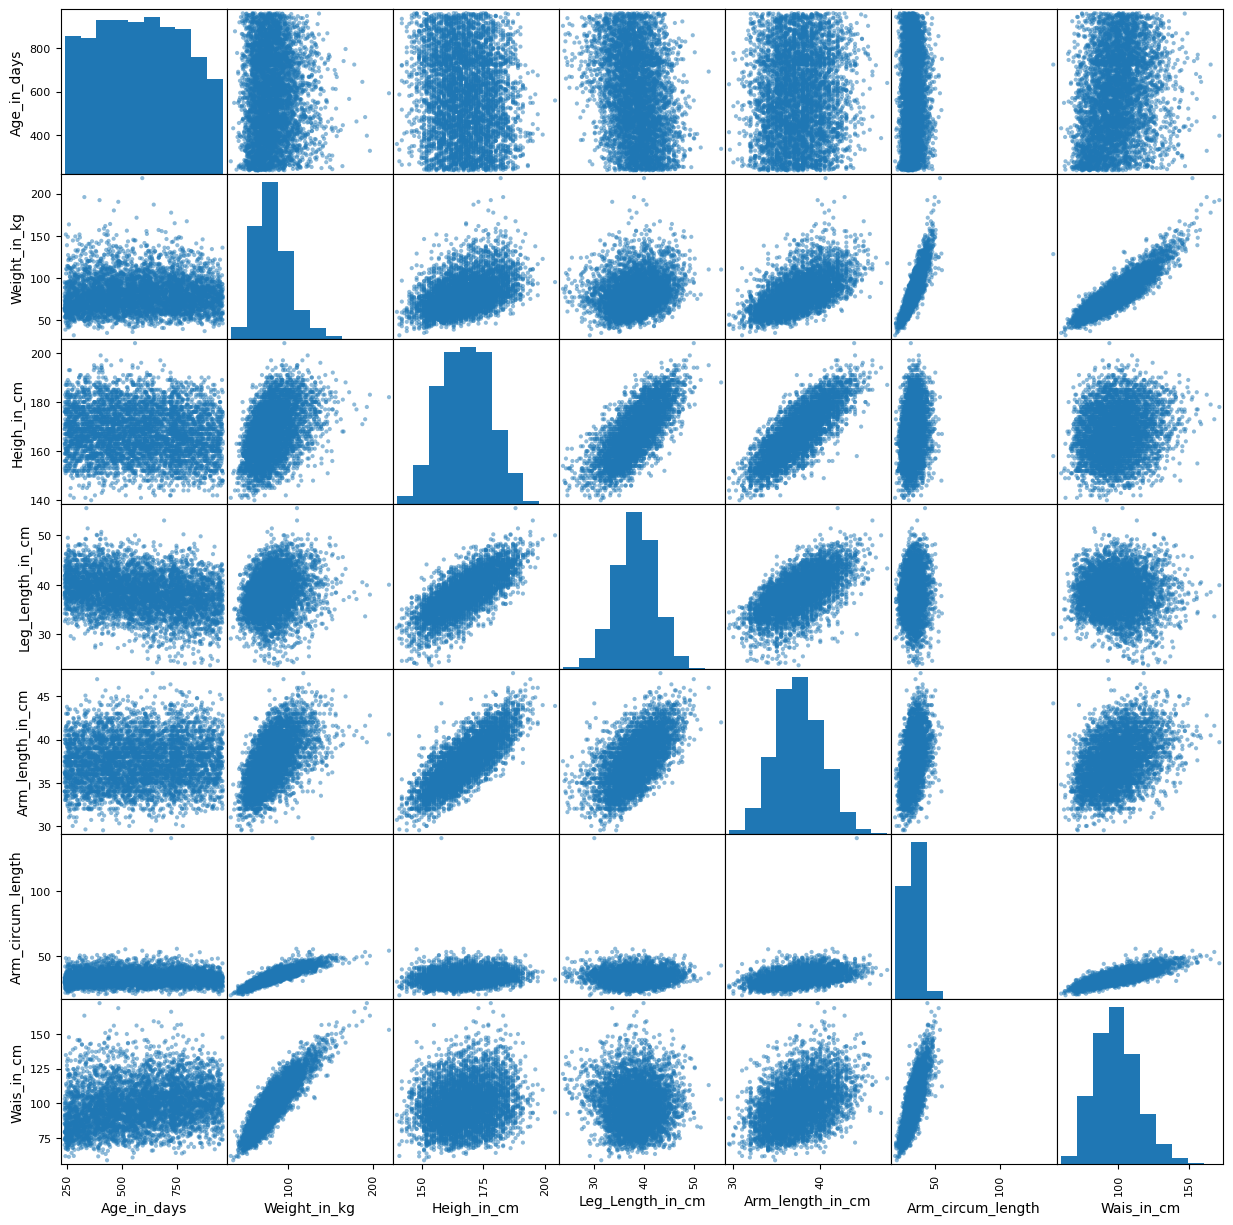

In [12]:
plt.figure(figsize=(15,15))
df_without_gender = df[cols[1::]]

pd.plotting.scatter_matrix(df_without_gender, figsize=(15,15), grid=True)

## Findings 

- The heavier the person, the more likely they are to be male.
- The taller the person, the more likely they are to have longer arms and legs.
- The heavier the person, the bigger their waist circumference is likely to be.


In [14]:
correlation_df = pd.DataFrame.corr(df_without_gender)
correlation_df

,Age_in_days,Weight_in_kg,Heigh_in_cm,Leg_Length_in_cm,Arm_length_in_cm,Arm_circum_length,Wais_in_cm
Age_in_days,1.000000,0.017480,-0.105107,-0.268362,0.053667,0.009340,0.227538
Weight_in_kg,0.017480,1.000000,0.442543,0.237047,0.584044,0.859518,0.891869
Heigh_in_cm,-0.105107,0.442543,1.000000,0.745212,0.799729,0.212407,0.181536
Leg_Length_in_cm,-0.268362,0.237047,0.745212,1.000000,0.612864,0.075998,-0.028937
Arm_length_in_cm,0.053667,0.584044,0.799729,0.612864,1.000000,0.434724,0.401728
Arm_circum_length,0.009340,0.859518,0.212407,0.075998,0.434724,1.000000,0.820541
Wais_in_cm,0.227538,0.891869,0.181536,-0.028937,0.401728,0.820541,1.000000


(3) Als Fortsetzung zu Schritt (2): Welche Vermutungen haben Sie, die die beobachtete Korrelation zwischen Alter und Körpergröße sowie zwischen Gewicht und Taillenumfang erklären könnte? 

ABOVE

Sie haben bisher die Schritte einer Explorativen Datenanalyse (EDA) nachvollzogen, in der es darum geht, die Daten kennenzulernen (und ggf. interessante Hypothesen und Fragen zu generieren). Im nächsten Schritt wollen wir mit den Daten etwas erreichen: Wir möchten anhand der Merkmale entscheiden können, ob es sich um eine Frau oder einen Mann handelt (unser Ziel ist also eine binäre Klassifikation). Sobald wir mit einem konkreten Ziel an die Daten herantreten, ändert sich unser Blick auf die Daten. Wir befinden uns in der *Feature Engineering* (Merkmalsgenerierung) Phase, in der wir nach Eigenschaften suchen, um unser Ziel zu erreichen.

(4) Erzeugen Sie jeweils einen DataFrame für die Datensätze aller Frauen sowie für die Datensätze aller Männer. Untersuchen Sie, ob Sie Merkmale (außer *gender*) in den Daten finden, mit denen Sie zwischen den Geschlechtern unterscheiden können. Nutzen Sie dazu die Mittel der EDA, also Summary Statistics, Box-Plots, und so weiter. Notieren Sie sich vielversprechende Merkmale, die Ihnen die Unterscheidung zwischen den Geschlechtern erlauben könnten.

/tmp/ipykernel_1074998/2811707752.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i, j].boxplot(
/tmp/ipykernel_1074998/2811707752.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i, j].boxplot(
/tmp/ipykernel_1074998/2811707752.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i, j].boxplot(
/tmp/ipykernel_1074998/2811707752.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i, j].boxplot(
/tmp/ipykernel_1074998/2811707752.py:15: MatplotlibDeprecationWarning: The '

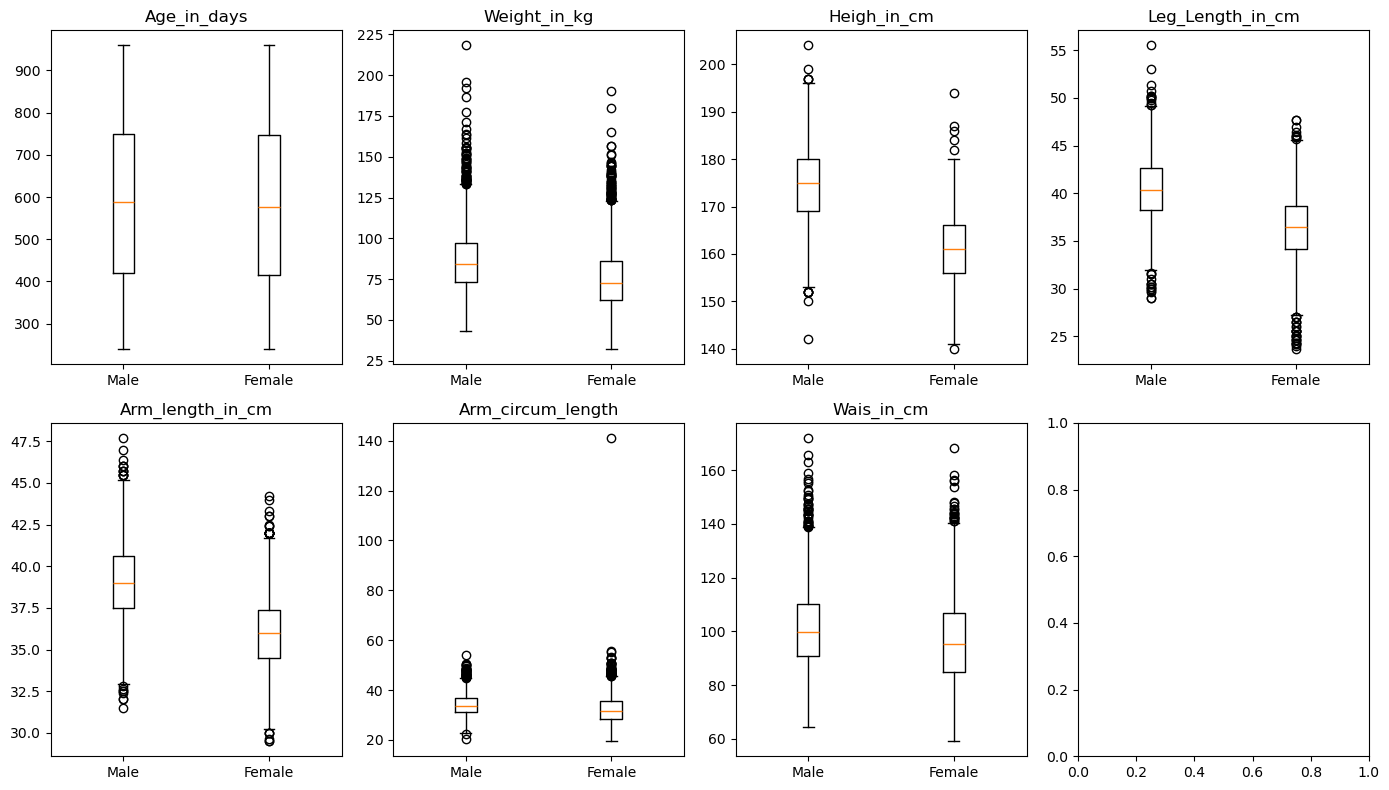

In [25]:
m_df = pd.DataFrame(df[df["Gender"] == 1])[cols[1::]]
f_df = pd.DataFrame(df[df["Gender"] == 0])[cols[1::]]

plotcols = cols[1::]

summary_male = m_df.describe()
summary_female = f_df.describe()

fig, axs = plt.subplots(2, 4, figsize=(14, 8))

i = 0
j = 0

for col in plotcols:
    axs[i, j].boxplot(
        [m_df[col].dropna(), f_df[col].dropna()],
        labels=["Male", "Female"]
    )
    axs[i, j].set_title(col)

    j += 1
    if j == 4:
        j = 0
        i += 1

plt.tight_layout()
plt.show()

Im nachfolgenden Schritt gebe ich Ihnen ein Merkmal vor, welches Sie sich im Folgenden anschauen werden. Ihre Arbeit in Schritt (4) war aber nicht vergebens. Wir kommen darauf später noch zurück.   

(5) Erzeugen Sie ein [Histogramm](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html), welches die Verteilung der Körpergrößen von Männern und von Frauen darstellt.

Text(0.5, 1.0, 'Height Female')

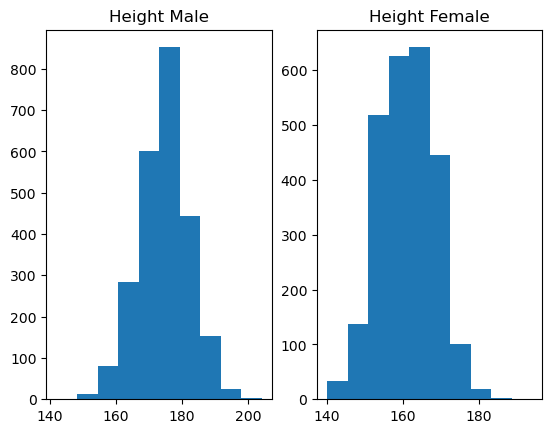

In [29]:
fig, ax = plt.subplots(1, 2)

ax[0].hist(m_df["Heigh_in_cm"])
ax[0].set_title("Height Male")
ax[1].hist(f_df["Heigh_in_cm"])
ax[1].set_title("Height Female")

(6) Wir werden ein einfaches Schwellwert-Modell konstruieren, um zwischen Männern und Frauen zu unterscheiden. Dieser sogenannte Klassifikator wird mithilfe eines Schwellwerts und eines Merkmals entscheiden, ob der Datensatz von einer Frau oder einem Mann stammt. Betrachten Sie die Abbildung aus Schritt (5). Notieren Sie sich hier den Schwellwert, den Sie nutzen würden, um alle Datensätze mit Körpergrößen größer als Ihr Schwellwert als Männer zu klassifizieren.

Der Schwellwert entscheidet darüber, wie gut oder wie schlecht ihr Klassifikator zwischen Frauen und Männern unterscheiden kann. Wir werden nun untersuchen, welche Genauigkeit unser Klassifikator hat und dabei auch einen Schwellwert finden, der die Genauigkeit des Klassifikators maximiert.

In [ ]:
# Choose a value between 165 and 180: 165

(7) Sie haben in Schritt (5) beobachtet, dass Männer (zumindest in dem von Ihnen untersuchten US-amerikanischen Datensatz) tendenziell etwas größer sind als Frauen. Sei $P$ die Anzahl der Männer und $N$ die Anzahl der Frauen im Datensatz. Bestimmen Sie die True Positive Rate (TPR) sowie die False Positive Rate (FPR) für den Schwellwert, für den Sie sich in Schritt (6) entschieden haben. Interpretieren Sie kurz Ihre erhaltenen Werte. (1-2 Sätze).

In [35]:
TP = len(m_df[m_df["Heigh_in_cm"] >= 165])
FP = len(f_df[f_df["Heigh_in_cm"] >= 165])
FN = len(m_df[m_df["Heigh_in_cm"] < 165])
TN = len(f_df[f_df["Heigh_in_cm"] < 165])

print(TP)
print(FP)
print(FN)
print(TN)

TRP = TP/(TP + FN)
print(TRP)



2205
794
247
1733
0.8992659053833605


(8) Wir wollen nun untersuchen, wie gut sich die Körpergröße für die Unterscheidung zwischen Männern und Frauen eignet, und welcher Schwellwert hier optimal ist. Dazu werden Sie für eine Menge von Schwellwerten die zugehörigen TPR und FPR-Werte bestimmen. Erstellen Sie zunächst eine Menge von Schwellwerten. Hinweis: Die Daten können Ihnen dabei helfen, Schwellwerte zu definieren.

In [41]:
def get_TRP_and_FNR(th):
    TP = len(m_df[m_df["Heigh_in_cm"] >= th])
    FP = len(f_df[f_df["Heigh_in_cm"] >= th])
    FN = len(m_df[m_df["Heigh_in_cm"] < th])
    TN = len(f_df[f_df["Heigh_in_cm"] < th])

    return (TP/(TP + FN), FP/(FP + TN))


height_summary_m = m_df["Heigh_in_cm"].describe()
height_summary_f = f_df["Heigh_in_cm"].describe()

ths = [160, 165, 170, 174 ,180]

t1, t2 = [], []

mx = 0
t = 0

for th in ths:
    TRP, FNR = get_TRP_and_FNR(th)
    t1.append(TRP)
    t2.append(FNR)

    if TRP >= mx:
        mx = TRP
        t = th

print(mx)
print(t)



0.9718597063621534
160


(9) Bestimmen Sie TPR und FPR für Ihre Schwellwerte aus Schritt (8). Tragen Sie in einem Plot die TPR-Werte (y-Achse) gegen die FPR-Werte (x-Achse) auf und zeichnen Sie zusätzlich die Raumdiagonale ein. Vergessen Sie nicht, Ihren Plot zu beschriften. Damit haben Sie Ihre *Receiver Operating Characteristic Curve* (ROC) erhalten. Ihre ROC-Kurve wird sich von der Raumdiagonalen unterscheiden. Was bedeutet dies? (1-2 Sätze).

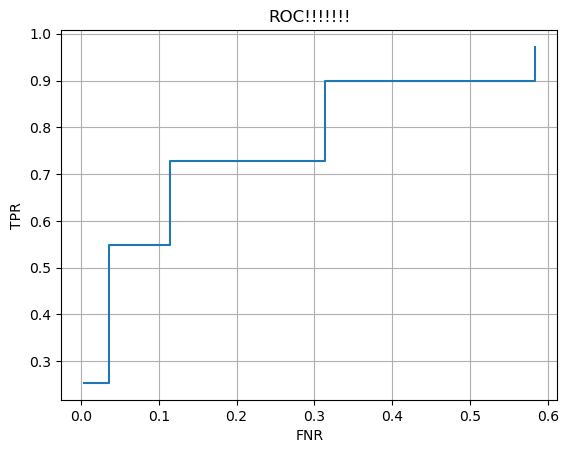

In [46]:
plt.step(t2, t1)
plt.xlabel("FNR")
plt.ylabel("TPR")
plt.title("ROC!!!!!!!")
plt.grid(True)

(10) Bestimmen Sie mit dem Youden-Index den optimalen Schwellwert zur Unterscheidung zwischen Frauen und Männern mithilfe der Körpergröße. Vergleichen Sie den erhaltenen Wert mit dem Wert, den Sie in Schritt (6) erhalten haben. (1-2 Sätze)

(11) Wir werden nun die ROC-Kurve durch eine skalare Größe charakterisieren, der *Area Under the Curve* (AUC). Nutzen Sie die [Sehnentrapezregel](https://de.wikipedia.org/wiki/Trapezregel#Sehnentrapezformel), um die Fläche unter Ihrer ROC-Kurve zu bestimmen und geben Sie den Wert der AUC aus. 
* Bevor Sie die AUC bestimmen, stellen Sie sicher, dass die TPR und FPR Werte in der richtigen Reihenfolge vorliegen ([Dies](https://docs.scipy.org/doc/numpy/reference/generated/numpy.flipud.html) kann Ihnen dabei helfen). 
* Welchen AUC-Wert würden Sie für einen Zufallsklassifikator (Zufallsprädiktor) erhalten?

(12) \[Optional\] Sie haben in Schritt (4) verschiedene Merkmale notiert, mithilfe derer Sie vermuteten, dass Sie Frauen und Männer voneinander unterscheiden könnten. Wählen Sie aus Schritt (4) ein oder zwei Merkmale heraus, die *nicht* der Körpergröße entsprechen. Bestimmen Sie für diese Merkmale die AUC. Sind Ihre Merkmale besser oder schlechter geeignet, um zwischen Männern und Frauen zu unterscheiden? 

###  11.2 Weinqualitäten (Multiklassen-Klassifikation, Feature Engineering)

In dieser Übung werden wir ein Nächste Nachbarn (NN) Modell erstellen, mit dem wir die Klasse eines Weines (d.h. die Kultursorte) aus den Eigenschaften vorhersagen können. Wir werden mit PCA-transformierten Merkmalen arbeiten.

**Ihre Daten**

Zu Beginn der 90er Jahre wurden verschiedene Weinproben in einer Region Italiens untersucht. Die Weine stammen von drei verschiedenen Kultursorten. Diese Kultursorten werden im unten hinterlegten Datensatz als Klasse 1, 2 und 3 (*class labels*) bezeichnet. Unter den 13 untersuchten Merkmalen finden Sie neben chemischen Eigenschaften (Alkoholgehalt, Säuregehalt) auch physikalische Eigenschaften (Farbintensität, etc).

Der Datensatz wird in zwei Teile geteilt: Der erste Datensatz ist der sogenannte Trainingsdatensatz, mithilfe dessen Sie ihr Modell erstellen. Der zweite Datensatz ist der sogenannte Testdatensatz, auf dem Sie ihr Modell anwenden und testen.

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import zscore
from sklearn.model_selection import train_test_split

# import data
column_names = ['Class label', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols', 'Flavanoids', 
                'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline']
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data', header=None)
df.columns = column_names

# preprocess data
# removing the label for the training data and also keeping only the numerical values
X, y = df.iloc[:, 1:].values, df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=10)

X_train, X_test = zscore(X_train), zscore(X_test)

# apply PCA
pca = PCA(n_components=2)
X_train_p = pca.fit_transform(X_train)
X_test_p = pca.transform(X_test)


array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))

**Ihre Aufgaben**

(1) Importieren Sie die Daten, indem Sie die obere Code-Zelle ausführen.

(2) Vergegenwärtigen Sie sich die Eigenschaften des Wein-Datensatzes: Untersuchen Sie dazu das Pandas-Objekt. Welche Eigenschaften wurden für die Weine erfasst? Wie viele Weinproben wurden genommen?

In [49]:
n_samples, m_features = df.shape

print(n_samples)
print(m_features)

178
14


(3) Lesen Sie den Code ab dem Kommentar `# preprocess data`. Was passiert in diesen Code-Zeilen? Welches Feature-Engineering findet statt, bis wir zu den Daten `X_train_p, X_test_p` angekommen sind, mit denen Sie dann arbeiten werden? Wie viele Features (Merkmale) haben die transformierten Daten?

In [ ]:
# OBEN


(72, 2)

(4) Visualisieren Sie in zwei Scatterplots den PCA-transformierten Trainingsdatensatz sowie den Testdatensatz. Färben Sie die Punkte in beiden Plots ein gemäß der Klassenzugehörigkeit, wie Sie in Ihrem Vektor `y_train` bzw. `y_test` kodiert ist. Die Einträge in `y_train` und `y_test` werden auch *Labels* genannt.

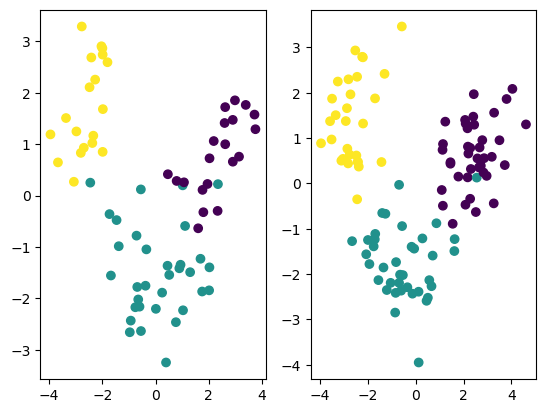

In [65]:
fig, ax = plt.subplots(1, 2)
ax[0].scatter(X_test_p[:, 0], X_test_p[:, 1], c=y_test)
ax[1].scatter(X_train_p[:, 0], X_train_p[:, 1], c=y_train)

(5) Wir werden jetzt ein NN-Modell (Nächste Nachbarn Modell) erstellen. Schreiben Sie dazu eine Funktion mit dem Namen `NN`, die die Trainingsdaten (`X_train_p` und `y_train_p`) sowie die Testdaten (`X_test_p`) entgegennimmt und die vorhergesagten Klassen (Labels) für die Testdaten als Vektor (`y_pred`) zurückgibt. Nutzen Sie für die Implementierung NumPy Funktionen. Broadcasting kann hilfreich sein.  

In [82]:
from collections import Counter

class NN:
    def __init__(self, k=5) -> None:
        self.k = 5

    def fit(self, X, y):
        self.X = X
        self.y = y
        self.n_samples, self.m_features = X.shape

    def predict(self, X_test):
        return np.array([self._majority_vote(x) for x in X_test])

    def _majority_vote(self, x):

       dists = [np.linalg.norm(x - self.X[i]) for i in range(self.n_samples)] 
       indices = np.argsort(dists)[1:self.k + 1]
       majority = Counter(self.y[indices]).most_common(1)[0][0]

       return majority

nn = NN(5)

nn.fit(X_train_p, y_train)
p = nn.predict(X_test_p)

acc = np.sum([1 if p[i] == y_test[i] else 0 for i in range(len(p))])/len(p)

print(acc)


0.9027777777777778


(6) Sie haben in Schritt (5) ein einfaches Machine Learning Modell implementiert, einen Klassifikator. Sagen Sie mithilfe Ihrer Funktion die Labels (Klassen) der Weinproben des Testdatensatzes voraus und speichern Sie die Voraussage im Vektor `y_pred`.

In [ ]:
# OBEN

(7) Bestimmen Sie die *Accuracy* Ihrer Vorhersage, also den Anteil der korrekt vorhergesagten Klassen dividiert durch die Gesamtanzahl aller Vorhersagen. Beurteilen Sie anhand der *Accuracy*, ob Ihr Modell die Klassen des Testdatensatzes gut vorhersagen kann. 

In [83]:
# OBEN

(8) Bestimmen Sie eine *Confusion Matrix*, um Ihren Klassifikator besser einschätzen zu können:

 1. Bestimmen Sie die Confusion Matrix Ihres Klassifikators auf dem Testdatensatz.
 2. Visualisieren Sie die Confusion Matrix mithilfe der Matplotlib.
 3. Bestimmen Sie die Confusion Matrix mit [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html). Unterscheiden sich die Ergebnisse?

In [86]:
confussion_matrix = np.zeros(shape=(3, 3))

for i in range(len(p)):
    x, y = 0, 0
    if p[i] == y_test[i]:
        x, y = p[i], p[i]
    elif p[i] == 1 and y_test[i] == 2:
        x, y = 1, 2
    elif p[i] == 1 and y_test[i] == 3:
        x, y = 1, 3
    elif p[i] == 2 and y_test[i] == 1:
        x, y = 2, 1
    elif p[i] == 2 and y_test[i] == 3:
        x, y = 2, 3
    elif p[i] == 3 and y_test[i] == 1:
        x, y = 3, 1
    elif p[i] == 3 and y_test[i] == 2:
        x, y = 3, 2 
    confussion_matrix[x - 1, y - 1] += 1


confussion_matrix


array([[20.,  6.,  0.],
       [ 0., 26.,  0.],
       [ 0.,  1., 19.]])

(9) Interpretieren Sie die *Confusion Matrix*: Welche Klassen werden besser vorhergesagt, welche schlechter?